## Question 1

Data shape: (70000, 784)
Training the classifier...

Model Accuracy: 93.77%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1726
           1       0.96      0.99      0.97      1969
           2       0.91      0.93      0.92      1748
           3       0.91      0.92      0.91      1785
           4       0.93      0.95      0.94      1706
           5       0.91      0.90      0.91      1578
           6       0.96      0.95      0.95      1719
           7       0.96      0.95      0.95      1823
           8       0.94      0.89      0.91      1706
           9       0.94      0.91      0.92      1740

    accuracy                           0.94     17500
   macro avg       0.94      0.94      0.94     17500
weighted avg       0.94      0.94      0.94     17500



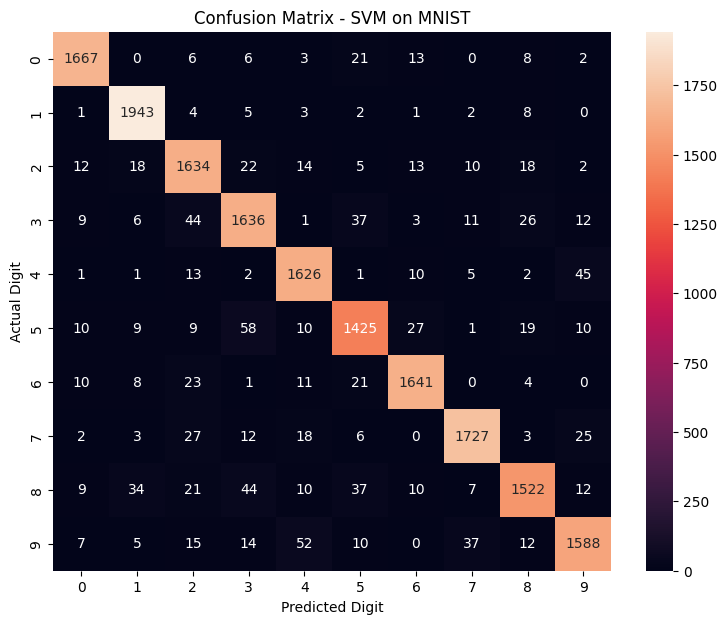

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Downloading MNIST dataset...")
dataset = fetch_openml(name="mnist_784", version=1, as_frame=False)

data = dataset.data
target = dataset.target.astype(np.int32)

print("Data shape:", data.shape)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(
    data_scaled,
    target,
    test_size=0.25, 
    random_state=0,
    stratify=target
)

classifier = SVC(kernel="linear", C=1.0)
print("Training the classifier...")
classifier.fit(X_train, y_train)


predicted = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predicted)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

print("\nDetailed Classification Report:")
print(classification_report(y_test, predicted))

cm = confusion_matrix(y_test, predicted)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM on MNIST")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()


Dataset loaded. Shape: (70000, 784)
Initializing SVM model (Kernel: Linear)...
Training complete.
Predicting on test set...

Accuracy: 93.51%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1343
           1       0.96      0.98      0.97      1600
           2       0.91      0.92      0.92      1380
           3       0.91      0.92      0.92      1433
           4       0.93      0.94      0.94      1295
           5       0.90      0.90      0.90      1273
           6       0.97      0.95      0.96      1396
           7       0.95      0.95      0.95      1503
           8       0.92      0.88      0.90      1357
           9       0.93      0.91      0.92      1420

    accuracy                           0.94     14000
   macro avg       0.93      0.93      0.93     14000
weighted avg       0.94      0.94      0.94     14000


Confusion Matrix:
[[1310    1    4    0    3   11    7    1    5    1]
 [ 

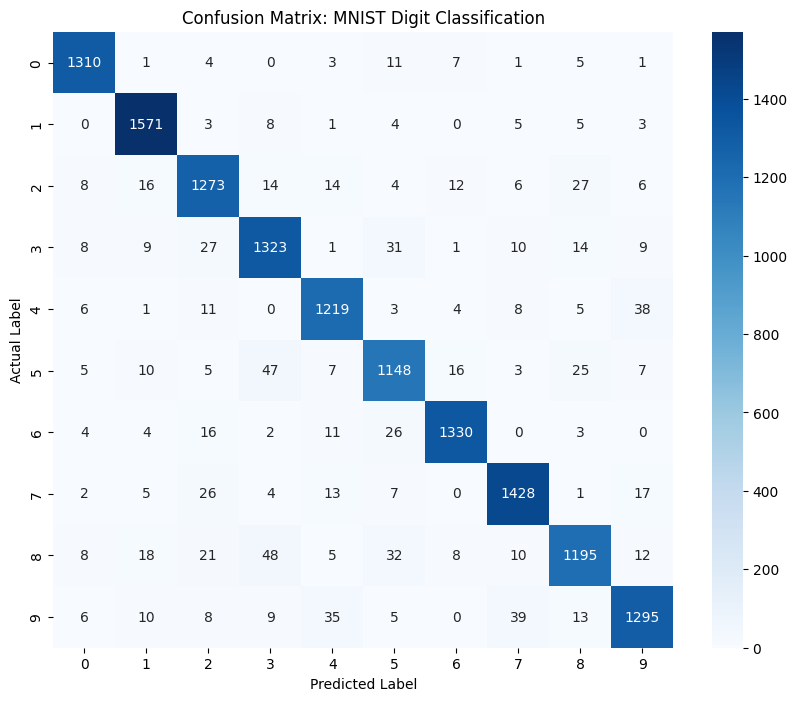

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

y = y.astype(int)

print(f"Dataset loaded. Shape: {X.shape}")
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Initializing SVM model (Kernel: Linear)...")
svm_model = SVC(kernel='linear', C=1.0, random_state=42)

svm_model.fit(X_train, y_train)
print("Training complete.")

print("Predicting on test set...")
y_pred = svm_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: MNIST Digit Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Question 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    "Species": [
        "Bream","Bream","Bream","Bream","Bream","Bream",
        "Roach","Roach","Roach","Roach","Roach","Roach","Roach"
    ],
    "Weight": [242,290,340,363,500,1000,200,180,290,390,160,140,40],
    "Length": [25.4,26.3,26.5,29,29.7,37,23.5,25.2,26,31.7,22.5,20.8,14.5],
    "Height": [11.52,12.48,12.73,12.75,13.65,18.9,7.3,7.10,8.88,9.5,6.5,6.4,4.15]
}

df = pd.DataFrame(data)

species_list = df["Species"].unique()

for sp in species_list:
    print(f"\nSpecies: {sp}")
    
    subset = df[df["Species"] == sp]
    
    X = subset[["Length"]]
    y = subset["Weight"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    slope = model.coef_[0]
    intercept = model.intercept_

    s = np.std(y, ddof=1)   
    n = len(y)
    SE = s / np.sqrt(n)
    
    print("Slope (m):", round(slope, 3))
    print("Intercept (c):", round(intercept, 3))
    print("Standard Error (SE):", round(SE, 3))
    
    print("Regression Equation:")
    print(f"Weight = {round(slope,3)} * Length + {round(intercept,3)}")




Species: Bream
Slope (m): 64.749
Intercept (c): -1420.802
Standard Error (SE): 114.503
Regression Equation:
Weight = 64.749 * Length + -1420.802

Species: Roach
Slope (m): 20.47
Intercept (c): -280.167
Standard Error (SE): 42.37
Regression Equation:
Weight = 20.47 * Length + -280.167


## Question 3

In [1]:
import numpy as np
import pandas as pd

# Data
lower = np.array([0,10,20,30,40,50,60,70,80])
upper = np.array([9,19,29,39,49,59,69,79,89])
freq  = np.array([20,21,23,16,11,10,7,3,1])

mid = (lower + upper) / 2
N = freq.sum()

# Mean
mean = (mid * freq).sum() / N

# Median
cum = np.cumsum(freq)
idx = np.where(cum >= N/2)[0][0]

L = lower[idx] - 0.5
cf_prev = cum[idx-1] if idx > 0 else 0
f = freq[idx]
w = upper[idx] - lower[idx] + 1

median = L + ((N/2 - cf_prev) / f) * w

# Mode
mode_idx = np.argmax(freq)
L = lower[mode_idx] - 0.5
f1 = freq[mode_idx]
f0 = freq[mode_idx-1]
f2 = freq[mode_idx+1]

mode = L + ((f1 - f0) / ((f1 - f0) + (f1 - f2))) * w

print("Estimated Mean =", round(mean, 2))
print("Estimated Median =", round(median, 2))
print("Estimated Mode =", round(mode, 2))


Estimated Mean = 29.5
Estimated Median = 26.02
Estimated Mode = 21.72


## Question 4

In [4]:
import math
s = 180     
n = 200      

SE = s / math.sqrt(n)

print("Standard Error =", round(SE, 2))


Standard Error = 12.73


## Question 5

In [6]:
import numpy as np
values = np.array([12, 23, 31, 15, 26, 24, 16, 23])

mean = np.mean(values)
absolute_diff = np.abs(values - mean)
average_distance = np.mean(absolute_diff)

print("Mean =", round(mean, 2))
print("Average Distance from Mean =", round(average_distance, 2))


Mean = 21.25
Average Distance from Mean = 5.19


## Question 6

In [2]:
import numpy as np

lower = np.array([2,4,6,8])
upper = np.array([4,6,8,10])
f = np.array([16,13,7,5])

mid = (lower + upper) / 2
N = f.sum()

# Mean
mean = (f * mid).sum() / N

# Standard Deviation
sd = np.sqrt((f * (mid - mean)**2).sum() / N)

# Median
cum = np.cumsum(f)
idx = np.where(cum >= N/2)[0][0]

L = lower[idx]
cf_prev = cum[idx-1] if idx > 0 else 0
w = upper[idx] - lower[idx]

median = L + ((N/2 - cf_prev) / f[idx]) * w

# Skewness (Karl Pearson)
skewness = (mean - median) / sd

print("Mean =", round(mean, 2))
print("Standard Deviation =", round(sd, 2))
print("Median =", round(median, 2))
print("Skewness =", round(skewness, 3))


Mean = 5.05
Standard Deviation = 2.05
Median = 4.69
Skewness = 0.174
